In [1]:
import marker_utils
import scanpy as sc
import marker_utils.save_data as save_data

Before inputting the scATAC-seq data, it must be preprocessed. We have provided a preprocessing script for this purpose.

python atac_processed.py --input atac_data_path --fpeak 0.05 --output ./

In [2]:
# Please ensure that the data's obs contains a celltype entry to indicate the cluster to which each cell belongs.
sc.read_h5ad('example_data/atac.h5ad')

AnnData object with n_obs × n_vars = 2088 × 140102
    obs: 'cell_type', 'cell_type_raw', 'celltype'
    var: 'peak'

In [3]:
# Run with the default parameters.
info,adata=marker_utils.getMarkersEI(adata_path='example_data/atac.h5ad')

------Loading data------
------Data transposition------
2088 cells, 140102 genes.
------Step1: Calculate PCA------
------Step2: Calculate the similarity matrix------
------Step3: Adjust the expression value------
------Step4: Calculate EI------


cluster:OCrunningcalculate_EI(6/6): 100%|█████| 5/5 [8:20:30<00:00, 6006.05s/it]


40.80 seconds used for calculate_mean_and_var.
29825.97 seconds used for calculate_smoothness.
1.69 seconds used for calculate_V.
11.02 seconds used for calculate_prop.
143.36 seconds used for calculate_local_mean_max.
6.76 seconds used for calculate_EI.
------Congratulations, success!------


In [4]:
# Print the first six Features.
six_features=info['AC'].sort_values(by='EI', ascending=False).head(6)['Features'].tolist()
info['AC'].sort_values(by='EI', ascending=False).head(6).reset_index(drop=True)

,Features,Mean,Smoothness,Local_max,V,Prop,Prop_sum,P,EI
0,chr3_50421761_50422261,0.350000,0.064868,0.133333,1.888457,1.586013e+15,5.746579,0.005581,0.079263
1,chr4_96719126_96719626,0.325000,0.067811,0.400000,1.557634,1.301879e+14,154.545778,0.038140,0.000175
2,chr5_115436434_115436934,0.333333,0.064387,0.333333,1.725673,2.995592e+14,893.704854,0.047442,0.000081
3,chr15_30693733_30694233,0.291667,0.073111,0.133333,1.163563,4.644323e+12,26.634278,0.021359,0.000031
4,chr8_93917767_93918267,0.308333,0.068820,0.266667,1.381423,2.458932e+13,322.080783,0.039683,0.000015
5,chr16_18083366_18083866,0.266667,0.073794,0.133333,0.963640,3.812292e+11,7.299099,0.007767,0.000008


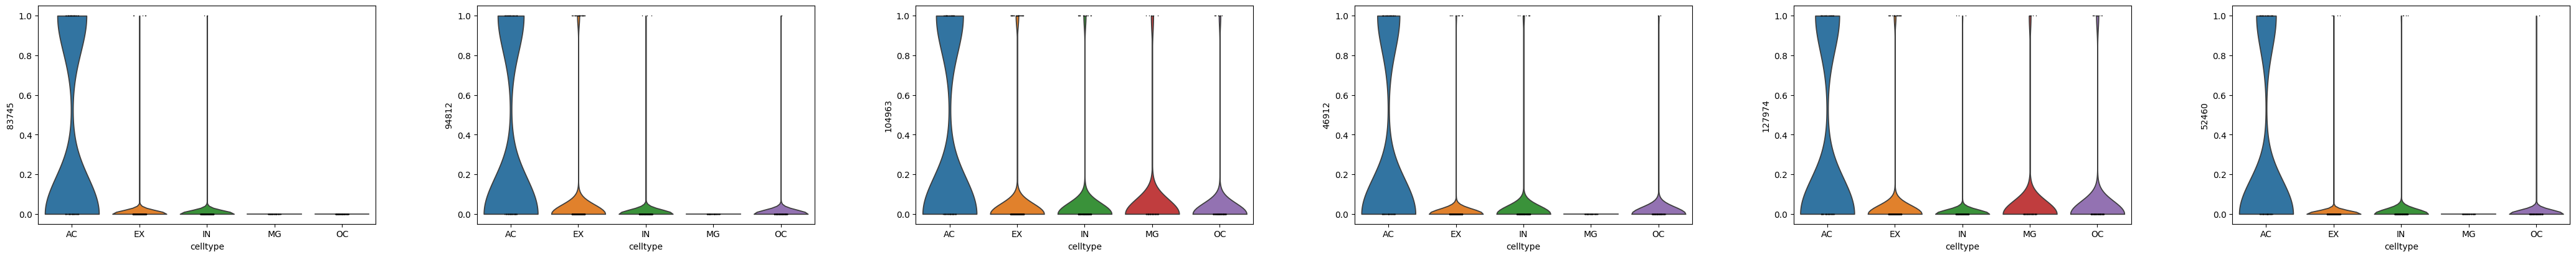

In [5]:
sc.pl.violin(adata,six_features,groupby="celltype")

In [6]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="celltype", method="wilcoxon")
sc.get.rank_genes_groups_df(adata, group="AC").head(6)

,names,scores,logfoldchanges,pvals,pvals_adj
0,chr3_50851055_50851555,6.370728,6.684835,1.881336e-10,0.000026
1,chr4_96719126_96719626,5.564093,4.053429,2.635192e-08,0.001341
2,chr18_5159883_5160383,5.511690,3.513957,3.554046e-08,0.001341
3,chr13_102573440_102573940,5.498589,3.842266,3.828420e-08,0.001341
4,chr5_115436434_115436934,5.361967,3.199105,8.232076e-08,0.002307
5,chr8_93917767_93918267,5.191656,3.753661,2.084315e-07,0.004867


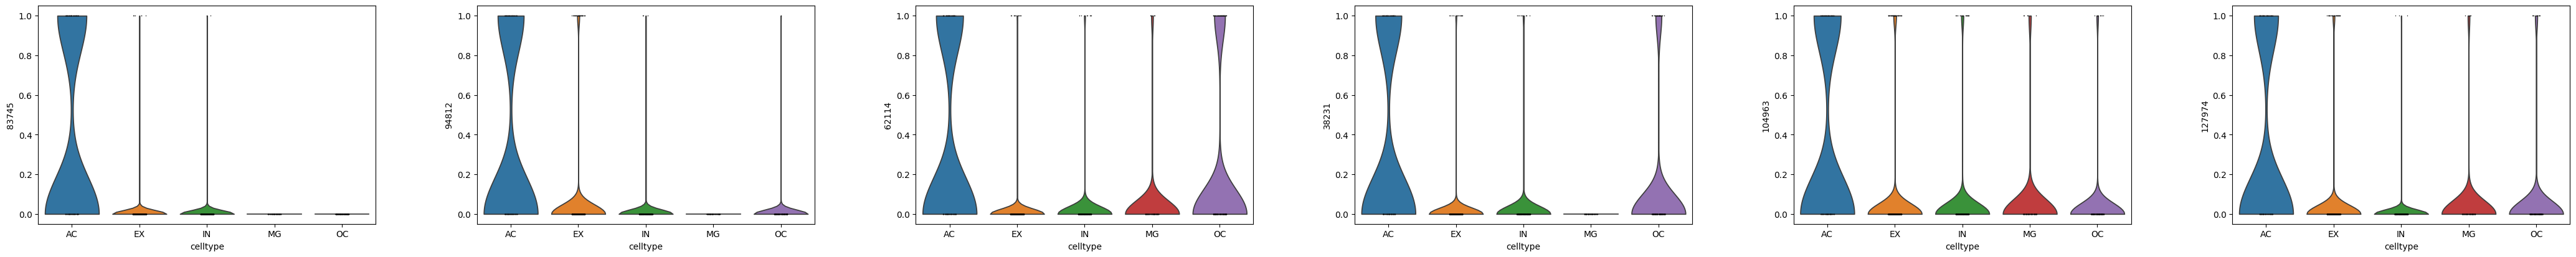

In [7]:
sc.pl.violin(adata,sc.get.rank_genes_groups_df(adata, group="AC").head(6)['names'].tolist(),groupby="celltype")